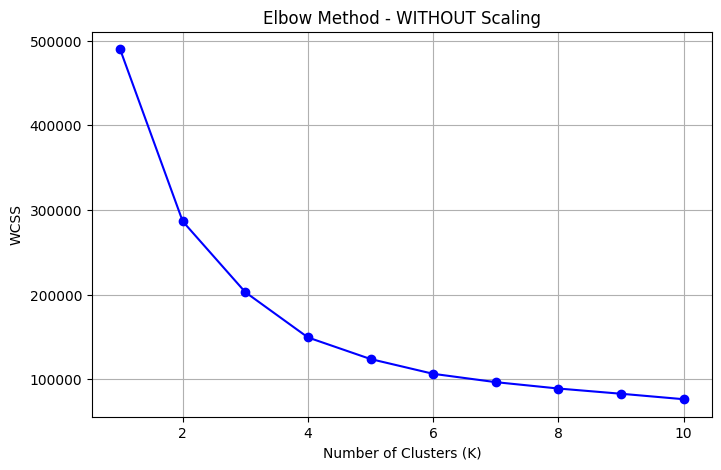

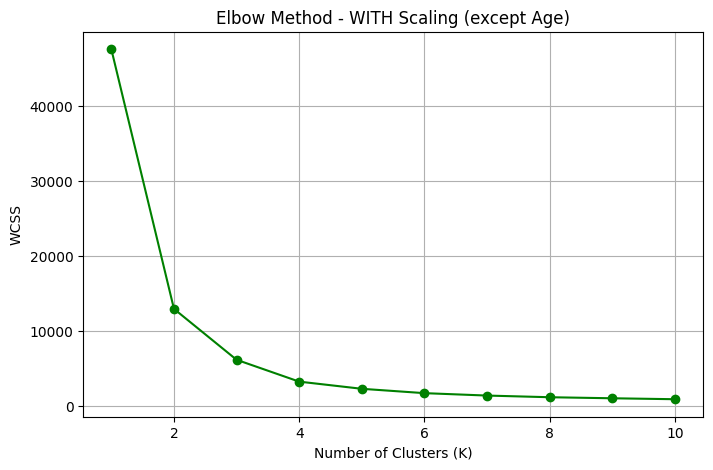

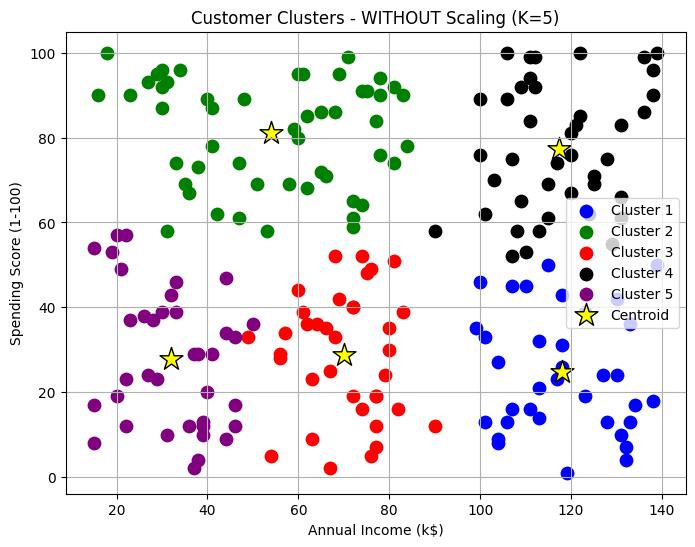

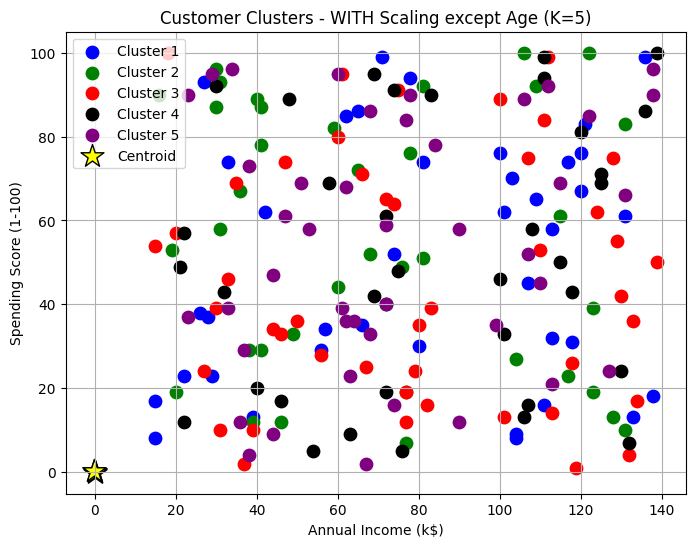

    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0            1    Male   49                  68                      86   
1            2  Female   56                  22                      57   
2            3    Male   66                  41                      29   
3            4    Male   69                  41                      78   
4            5    Male   49                 112                      92   
5            6  Female   21                  35                      69   
6            7    Male   47                  44                      47   
7            8    Male   54                 111                      94   
8            9    Male   40                  42                      62   
9           10  Female   56                 125                      69   
10          11    Male   62                  78                      76   
11          12    Male   32                 111                      16   
12          13    Male   

In [1]:
# TASK # 1
# In the example code above, customer segmentation was performed
# using only two features. Now, use all available features except
# customer_id to implement K-Means clustering. Perform the clustering
# twice — once without feature scaling, and once with scaling applied
# to all features except age. Compare the results and comment on the
# differences and insights observed from these changes.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 200
data = {
    'CustomerID':              range(1, n+1),
    'Gender':                  np.random.choice(['Male', 'Female'], n),
    'Age':                     np.random.randint(18, 70, n),
    'Annual Income (k$)':      np.random.randint(15, 140, n),
    'Spending Score (1-100)':  np.random.randint(1, 101, n)
}
df = pd.DataFrame(data)

le = LabelEncoder()
df['Gender_enc'] = le.fit_transform(df['Gender'])

features = ['Gender_enc', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

wcss_no_scale = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss_no_scale.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss_no_scale, 'o-', color='blue')
plt.title('Elbow Method - WITHOUT Scaling')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

X_scaled = X.copy().astype(float)
scaler = StandardScaler()
cols_to_scale = [0, 2, 3]
X_scaled[:, cols_to_scale] = scaler.fit_transform(X[:, cols_to_scale])

wcss_scaled = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss_scaled.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss_scaled, 'o-', color='green')
plt.title('Elbow Method - WITH Scaling (except Age)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

K = 5

kmeans_no = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)
y_no = kmeans_no.fit_predict(X)

kmeans_sc = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)
y_sc = kmeans_sc.fit_predict(X_scaled)

colors = ['blue', 'green', 'red', 'black', 'purple']

plt.figure(figsize=(8, 6))
for i in range(K):
    plt.scatter(X[y_no == i, 2], X[y_no == i, 3],
                s=80, c=colors[i], label=f'Cluster {i+1}')
plt.scatter(kmeans_no.cluster_centers_[:, 2],
            kmeans_no.cluster_centers_[:, 3],
            s=300, c='yellow', marker='*', label='Centroid', edgecolors='black')
plt.title('Customer Clusters - WITHOUT Scaling (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
for i in range(K):
    plt.scatter(X[y_sc == i, 2], X[y_sc == i, 3],
                s=80, c=colors[i], label=f'Cluster {i+1}')
plt.scatter(kmeans_sc.cluster_centers_[:, 2],
            kmeans_sc.cluster_centers_[:, 3],
            s=300, c='yellow', marker='*', label='Centroid', edgecolors='black')
plt.title('Customer Clusters - WITH Scaling except Age (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

df['Cluster_NoScale'] = y_no + 1
df['Cluster_Scaled']  = y_sc + 1
print(df[['CustomerID','Gender','Age','Annual Income (k$)',
          'Spending Score (1-100)','Cluster_NoScale','Cluster_Scaled']].head(20))

   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost vehicle_type
0                  5   150000               15              5000          SUV
1                  3   120000               18              4000        Sedan
2                  8   250000               10              7000        Truck
3                  2    80000               22              2000    Hatchback
4                  4   100000               20              3000        Sedan
5                  7   220000               12              6500        Truck
6                  6   180000               16              5500          SUV
7                 10   300000                8              8000        Truck
8                  1    75000               24              1500    Hatchback
9                  9   280000                9              7500          SUV


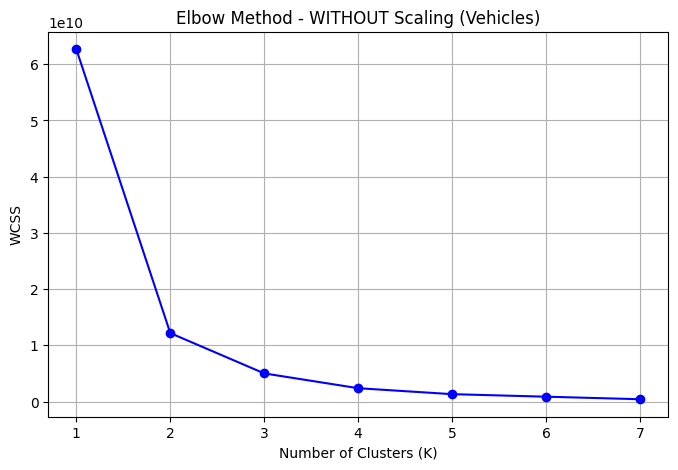

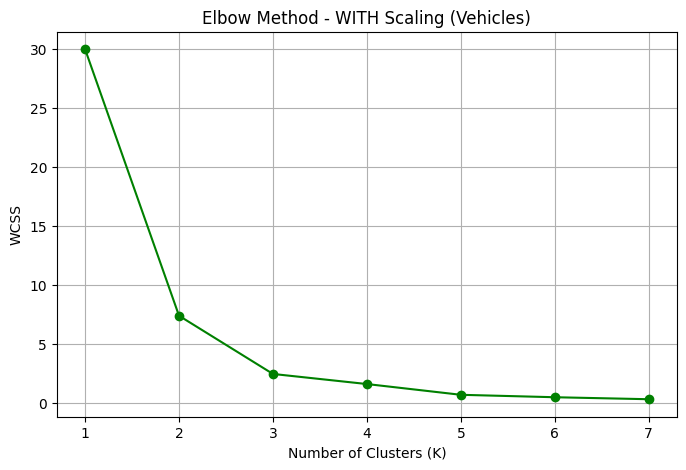

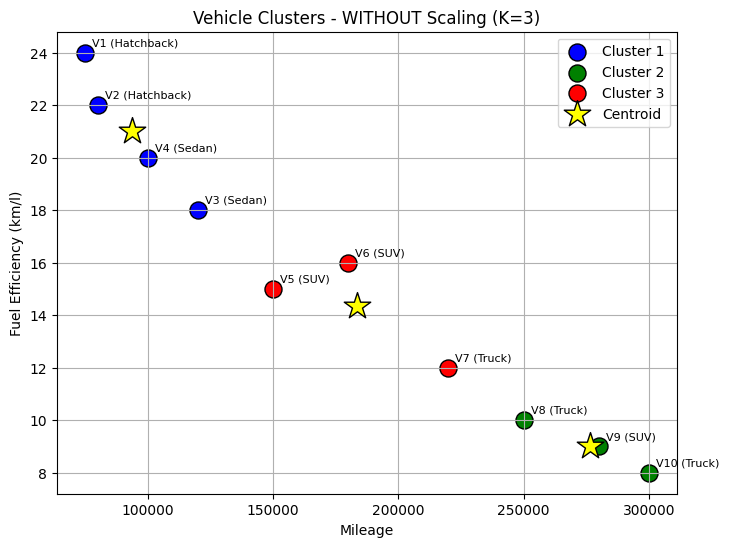

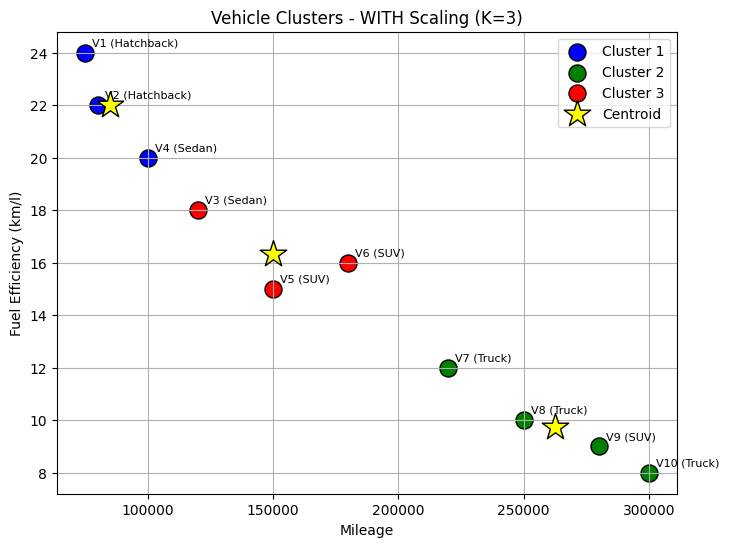

 vehicle_serial_no vehicle_type  mileage  fuel_efficiency  maintenance_cost  Cluster_NoScale  Cluster_Scaled
                 5          SUV   150000               15              5000                3               3
                 3        Sedan   120000               18              4000                1               3
                 8        Truck   250000               10              7000                2               2
                 2    Hatchback    80000               22              2000                1               1
                 4        Sedan   100000               20              3000                1               1
                 7        Truck   220000               12              6500                3               2
                 6          SUV   180000               16              5500                3               3
                10        Truck   300000                8              8000                2               2
                 1 

In [2]:
# TASK # 2
# A transportation company wants to optimize its routes and fleet
# by categorizing different types of vehicles based on their usage patterns.
# The company has data on several features such as: vehicle_serial_no,
# mileage, fuel_efficiency, maintenance_cost, and vehicle_type.
# The goal is to create segments of vehicles based on these attributes
# to help with fleet management. Implement K-Means clustering to group
# vehicles using all the features. Perform the clustering twice:
# once without scaling the features and once with scaling applied to all features
# (except for vehicle_type, which is categorical). Analyze and compare the results,
# focusing on how the scaling affects the clustering output.
# Sample Data:
# # Example vehicle data
# data = {
#     ‘vehicle_serial_no’: [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
#     'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
#     'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
#     'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
#     'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
# }
# # Create a DataFrame
# df = pd.DataFrame(data)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage':           [150000, 120000, 250000, 80000, 100000,
                          220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency':   [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost':  [5000, 4000, 7000, 2000, 3000, 6500,
                          5500, 8000, 1500, 7500],
    'vehicle_type':      ['SUV','Sedan','Truck','Hatchback','Sedan',
                          'Truck','SUV','Truck','Hatchback','SUV']
}
df = pd.DataFrame(data)
print(df)

features = ['mileage', 'fuel_efficiency', 'maintenance_cost']
X = df[features].values

wcss_no_scale = []
for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss_no_scale.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), wcss_no_scale, 'o-', color='blue')
plt.title('Elbow Method - WITHOUT Scaling (Vehicles)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss_scaled = []
for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss_scaled.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), wcss_scaled, 'o-', color='green')
plt.title('Elbow Method - WITH Scaling (Vehicles)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

K = 3

kmeans_no = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)
y_no = kmeans_no.fit_predict(X)

kmeans_sc = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)
y_sc = kmeans_sc.fit_predict(X_scaled)

colors = ['blue', 'green', 'red']

plt.figure(figsize=(8, 6))
for i in range(K):
    plt.scatter(X[y_no == i, 0], X[y_no == i, 1],
                s=150, c=colors[i], label=f'Cluster {i+1}', edgecolors='black')
for idx, row in df.iterrows():
    plt.annotate(f"V{int(row['vehicle_serial_no'])} ({row['vehicle_type']})",
                 (row['mileage'], row['fuel_efficiency']),
                 fontsize=8, xytext=(5, 5), textcoords='offset points')
plt.scatter(kmeans_no.cluster_centers_[:, 0],
            kmeans_no.cluster_centers_[:, 1],
            s=400, c='yellow', marker='*', label='Centroid', edgecolors='black', zorder=5)
plt.title('Vehicle Clusters - WITHOUT Scaling (K=3)')
plt.xlabel('Mileage')
plt.ylabel('Fuel Efficiency (km/l)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
for i in range(K):
    plt.scatter(X[y_sc == i, 0], X[y_sc == i, 1],
                s=150, c=colors[i], label=f'Cluster {i+1}', edgecolors='black')
for idx, row in df.iterrows():
    plt.annotate(f"V{int(row['vehicle_serial_no'])} ({row['vehicle_type']})",
                 (row['mileage'], row['fuel_efficiency']),
                 fontsize=8, xytext=(5, 5), textcoords='offset points')
centers_orig = scaler.inverse_transform(kmeans_sc.cluster_centers_)
plt.scatter(centers_orig[:, 0], centers_orig[:, 1],
            s=400, c='yellow', marker='*', label='Centroid', edgecolors='black', zorder=5)
plt.title('Vehicle Clusters - WITH Scaling (K=3)')
plt.xlabel('Mileage')
plt.ylabel('Fuel Efficiency (km/l)')
plt.legend()
plt.grid(True)
plt.show()

df['Cluster_NoScale'] = y_no + 1
df['Cluster_Scaled']  = y_sc + 1
print(df[['vehicle_serial_no','vehicle_type','mileage',
          'fuel_efficiency','maintenance_cost',
          'Cluster_NoScale','Cluster_Scaled']].to_string(index=False))

  student_id   GPA  study_hours  attendance_rate
0       S001  3.84         18.9             90.4
1       S002  3.41         14.3             88.6
2       S003  3.51         19.7             94.5
3       S004  3.58         25.1             92.5
4       S005  3.34         18.8             91.7
5       S006  3.50         17.3             95.1
6       S007  3.50         16.4             94.0
7       S008  3.15         16.8             93.4
8       S009  3.70         19.1             95.9
9       S010  3.62         16.5             93.1


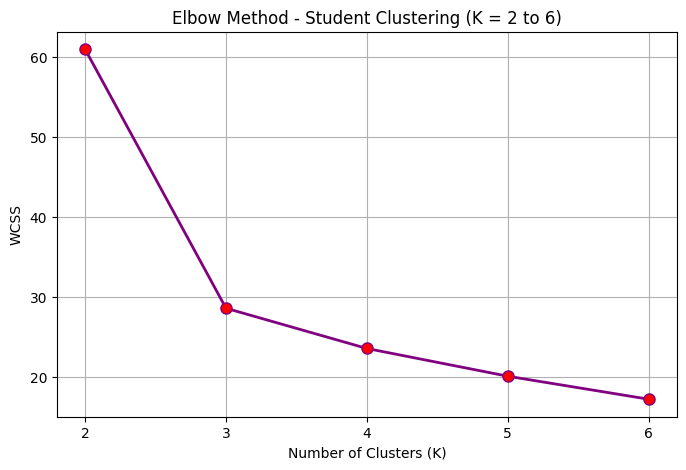

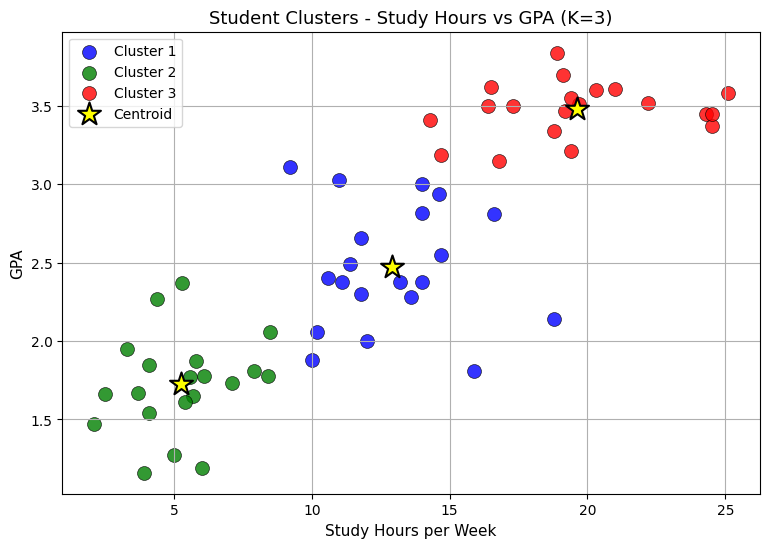

          GPA  study_hours  attendance_rate
Cluster                                    
1        2.47        12.92            73.72
2        1.72         5.24            54.73
3        3.48        19.62            91.06
student_id  GPA  study_hours  attendance_rate  Cluster          Profile
      S001 3.84         18.9             90.4        3  High Performers
      S002 3.41         14.3             88.6        3  High Performers
      S003 3.51         19.7             94.5        3  High Performers
      S004 3.58         25.1             92.5        3  High Performers
      S005 3.34         18.8             91.7        3  High Performers
      S006 3.50         17.3             95.1        3  High Performers
      S007 3.50         16.4             94.0        3  High Performers
      S008 3.15         16.8             93.4        3  High Performers
      S009 3.70         19.1             95.9        3  High Performers
      S010 3.62         16.5             93.1        3  High

In [4]:
# TASK # 3
# The academic affairs department at FAST NUCES Karachi is looking
# to identify distinct groups of students based on their academic
# engagement and performance. The department has access to anonymized
# student data containing the attributes student_id, GPA, study_hours
#  (average weekly study hours), and attendance_rate (percentage of classes attended).
# The goal is to group students into meaningful clusters that can help tailor academic
# support programs, such as extra tutoring, mentoring sessions, or motivation workshops.
# You are required to perform unsupervised learning using K-Means clustering on the student dataset.
# Do following :
# ●	Feature Selection and Scaling: Use the following features for clustering: GPA, study_hours, and attendance_rate.
# ●	Apply appropriate feature scaling before clustering.
# ●	Determine Optimal Number of Clusters (K): Use the ELbow  method to determine the optimal number of clusters (K) in the range of 2 to 6.
# ●	Perform Clustering: Apply K-Means using the optimal K and assign a cluster label to each student.
# ●	Visualization: Create a scatter plot to visualize the clusters using study_hours and GPA as the axes.
# ●	Color each point based on its cluster.
# ●	Add an informative title and labels for clarity.
# ●	Deliverables: Display the final dataset showing student IDs along with their assigned cluster.
# ●	Present the scatter plot that illustrates the clustering result.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(7)
n = 60

student_data = {
    'student_id': [f'S{str(i).zfill(3)}' for i in range(1, n+1)],
    'GPA': np.round(np.concatenate([
        np.random.normal(3.5, 0.2, 20),
        np.random.normal(2.5, 0.3, 20),
        np.random.normal(1.7, 0.3, 20),
    ]).clip(0, 4), 2),
    'study_hours': np.round(np.concatenate([
        np.random.normal(20, 3, 20),
        np.random.normal(12, 3, 20),
        np.random.normal(5, 2, 20),
    ]).clip(1, 35), 1),
    'attendance_rate': np.round(np.concatenate([
        np.random.normal(92, 4, 20),
        np.random.normal(75, 7, 20),
        np.random.normal(55, 10, 20),
    ]).clip(0, 100), 1),
}
df = pd.DataFrame(student_data)
print(df.head(10))

features = ['GPA', 'study_hours', 'attendance_rate']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss_list = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss_list.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss_list, 'o-', color='purple', linewidth=2,
         markersize=8, markerfacecolor='red')
plt.title('Elbow Method - Student Clustering (K = 2 to 6)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(list(k_range))
plt.grid(True)
plt.savefig('task3_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

K = 3

kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled) + 1

colors = ['blue', 'green', 'red']

plt.figure(figsize=(9, 6))
for i in range(1, K+1):
    mask = df['Cluster'] == i
    plt.scatter(df.loc[mask, 'study_hours'], df.loc[mask, 'GPA'],
                s=100, c=colors[i-1], label=f'Cluster {i}',
                edgecolors='black', linewidth=0.5, alpha=0.8)
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_orig[:, 1], centers_orig[:, 0],
            s=300, c='yellow', marker='*',
            edgecolors='black', linewidth=1.5, zorder=5, label='Centroid')
plt.title(f'Student Clusters - Study Hours vs GPA (K={K})', fontsize=13)
plt.xlabel('Study Hours per Week', fontsize=11)
plt.ylabel('GPA', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True)
plt.savefig('task3_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

cluster_profile = df.groupby('Cluster')[features].mean().round(2)
print(cluster_profile)

profile_sorted = cluster_profile.sort_values('GPA', ascending=False)
names = ['High Performers', 'Average Students', 'At-Risk Students']
name_map = {cid: name for cid, name in zip(profile_sorted.index, names[:K])}
df['Profile'] = df['Cluster'].map(name_map)

print(df[['student_id', 'GPA', 'study_hours', 'attendance_rate',
          'Cluster', 'Profile']].to_string(index=False))